        crim     rm     dis  tax  medv
0    0.00632  6.575  4.0900  296  24.0
1    0.02731  6.421  4.9671  242  21.6
2    0.02729  7.185  4.9671  242  34.7
3    0.03237  6.998  6.0622  222  33.4
4    0.06905  7.147  6.0622  222  36.2
..       ...    ...     ...  ...   ...
501  0.06263  6.593  2.4786  273  22.4
502  0.04527  6.120  2.2875  273  20.6
503  0.06076  6.976  2.1675  273  23.9
504  0.10959  6.794  2.3889  273  22.0
505  0.04741  6.030  2.5050  273  11.9

[506 rows x 5 columns] 

0      M
1      M
2      M
3      M
4      M
      ..
501    M
502    M
503    M
504    M
505    M
Length: 506, dtype: str 

category 

(506, 6) 

      crim     rm     dis  tax  medv grp
0  0.00632  6.575  4.0900  296  24.0   M
1  0.02731  6.421  4.9671  242  21.6   M
2  0.02729  7.185  4.9671  242  34.7   H
3  0.03237  6.998  6.0622  222  33.4   H
4  0.06905  7.147  6.0622  222  36.2   H 

crim     float64
rm       float64
dis      float64
tax        int64
medv     float64
grp     category
dtype: ob

C:\Users\user\AppData\Local\Temp\ipykernel_17592\701396803.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\user\AppData\Local\Temp\ipykernel_17592\701396803.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\user\AppData\Local\Temp\ipykernel_17592\701396803.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


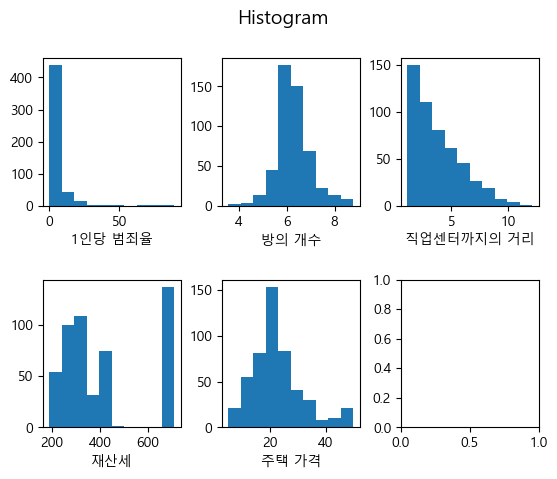

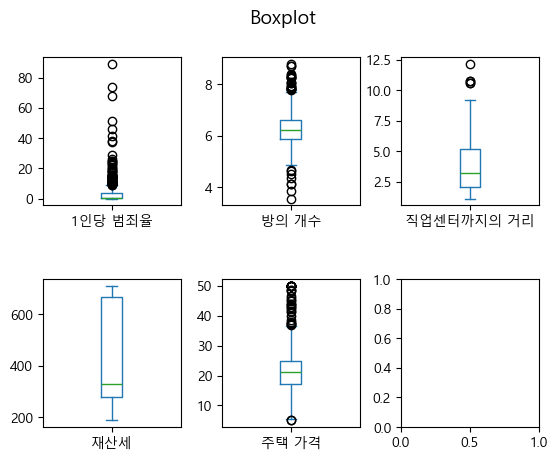

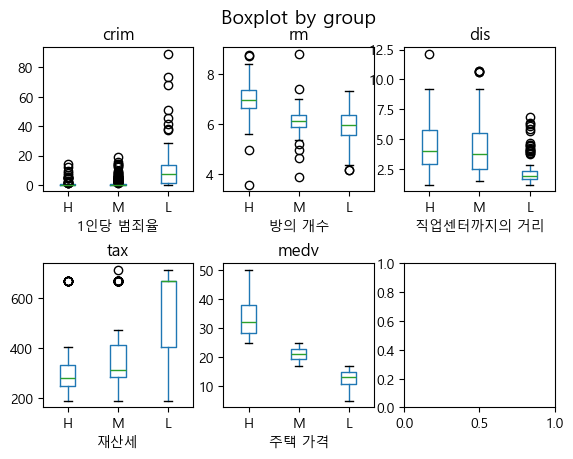

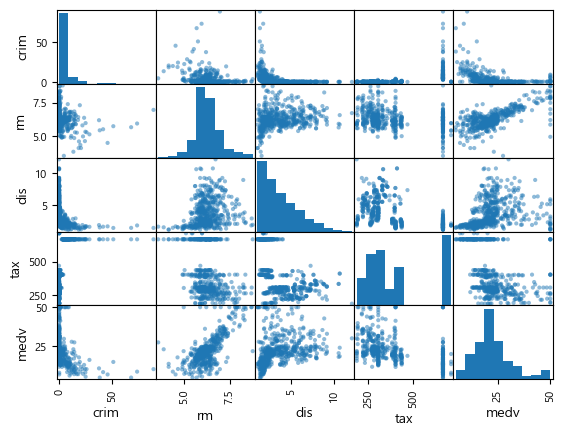

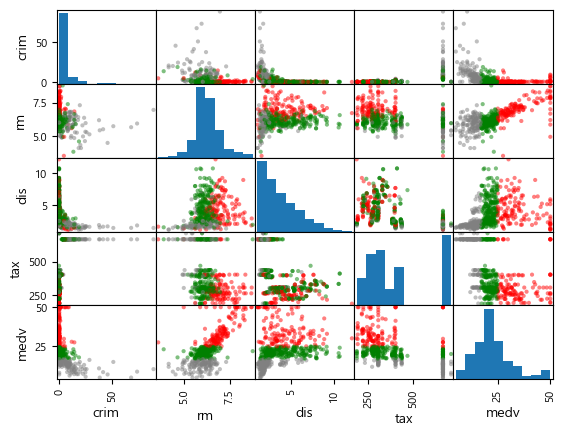

          crim        rm       dis       tax      medv
crim  1.000000 -0.219247 -0.379670  0.582764 -0.388305
rm   -0.219247  1.000000  0.205246 -0.292048  0.695360
dis  -0.379670  0.205246  1.000000 -0.534432  0.249929
tax   0.582764 -0.292048 -0.534432  1.000000 -0.468536
medv -0.388305  0.695360  0.249929 -0.468536  1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/BostonHousing.csv')
df = df[['crim', 'rm', 'dis', 'tax', 'medv']]
print(df, '\n')

titles = ['1인당 범죄율', '방의 개수', '직업센터까지의 거리', '재산세', '주택 가격']

# 그룹 컬럼 추가
grp = pd.Series(['M' for i in range(len(df))])
print(grp, '\n')
grp.loc[df.medv >= 25.0] = 'H'
grp.loc[df.medv <= 17.0] = 'L'
df['grp'] = grp

# 그룹 컬럼의 자료형과 레이블 순서 변경
new_odr = ['H', 'M', 'L']
new_dtype = CategoricalDtype(categories = new_odr, ordered = True)
df.grp = df.grp.astype(new_dtype)
print(df.grp.dtype, '\n')

# 데이터셋 형태과 기본 내용 파악
print("데이터셋 형태과 기본 내용 파악")
print(df.shape, '\n')
print(df.head(), '\n')
print(df.dtypes, '\n')
print(df.grp.value_counts(sort = False), '\n')

#히스토그램으로 관측값의 분포 확인
fig, axes = plt.subplots(nrows = 2, ncols = 3)
fig.subplots_adjust(hspace = 0.5, wspace = 0.3)

for i in range(5):
    df[df.columns[i]].plot.hist(ax = axes[i // 3, i % 3], ylabel = '', xlabel = titles[i])

fig.suptitle('Histogram', fontsize = 14)

fig.show()

# 상자그림으로 관측값 분포 확인
fig, axes = plt.subplots(nrows = 2, ncols = 3)
fig.subplots_adjust(hspace = 0.5, wspace = 0.3)

for i in range(5):
    df[df.columns[i]].plot.box(ax = axes[i // 3, i % 3], label = titles[i])

fig.suptitle('Boxplot', fontsize = 14)
fig.show()

# 그룹별 관측값의 분포 확인
fig, axes = plt.subplots(nrows = 2, ncols = 3)
fig.subplots_adjust(hspace = 0.5, wspace = 0.3)

for i in range(5):
    df.boxplot(column = df.columns[i], by = 'grp', grid = False, ax = axes[i // 3, i % 3], xlabel = titles[i])


fig.suptitle('Boxplot by group', fontsize = 14)
fig.show()

pd.plotting.scatter_matrix(df.iloc[:, :5])
plt.show()

# 그룹 정보를 포함한 변수 간 상관관계의 확인
dict = {'H' : 'red', 'M' : 'green', 'L' : 'gray'}
colors = list(dict[key] for key in df.grp)

pd.plotting.scatter_matrix(df.iloc[:, :5], c = colors)
plt.show()

print(df.iloc[:, :5].corr())
